In [12]:
from _setup import setup_project_root
PROJECT_ROOT = setup_project_root()

In [13]:
import importlib
import pandas as pd
import joblib
import evaluation.metrics as metrics
from models.XGBoost import XGBoostBaseConfig, build_xy, fit_model, predict

In [14]:
train_path = PROJECT_ROOT / "data" / "station_split" / "train.csv"
val_path   = PROJECT_ROOT / "data" / "station_split" / "val.csv"
test_path  = PROJECT_ROOT / "data" / "station_split" / "test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

In [15]:
pm25_scaler = joblib.load(PROJECT_ROOT / "artifacts" / "pm25_scaler.pkl")

In [16]:
config = XGBoostBaseConfig(
    time_col="date", 
    lags=24, 
    horizon=24,
    xgb_params={
        "n_estimators": 1000,
        "max_depth": 9,
        "tree_method": "hist",
        "learning_rate": 0.01,
        "random_state": 42
    }
)

In [17]:
X_train, y_train = build_xy(train_df, config, extra_feature_cols=['Station_No'])
X_val, y_val     = build_xy(val_df, config, extra_feature_cols=['Station_No'])
X_test, y_test   = build_xy(test_df, config, extra_feature_cols=['Station_No'])

In [ ]:
model_global = fit_model(X_train, y_train, config)
pred_test = predict(model_global, X_test)
res = metrics.compute_metrics_real_scale(y_test, pred_test, scaler=pm25_scaler)
print("Global XGBoost Results:", res)

Global XGBoost Results: {'Correlation': 0.5392666018481503, 'RMSE': 0.14733907585857076, 'MAPE': 0.4122034897229501, 'MAE': 0.10586582911473989}


Plot

In [21]:
%load_ext autoreload
%autoreload 2

from evaluation.plots import (
    plot_actual_vs_pred,
    plot_scatter_actual_pred,
    plot_residuals_vs_pred,
    plot_error_distribution,
    plot_actual_vs_pred_by_station,
)


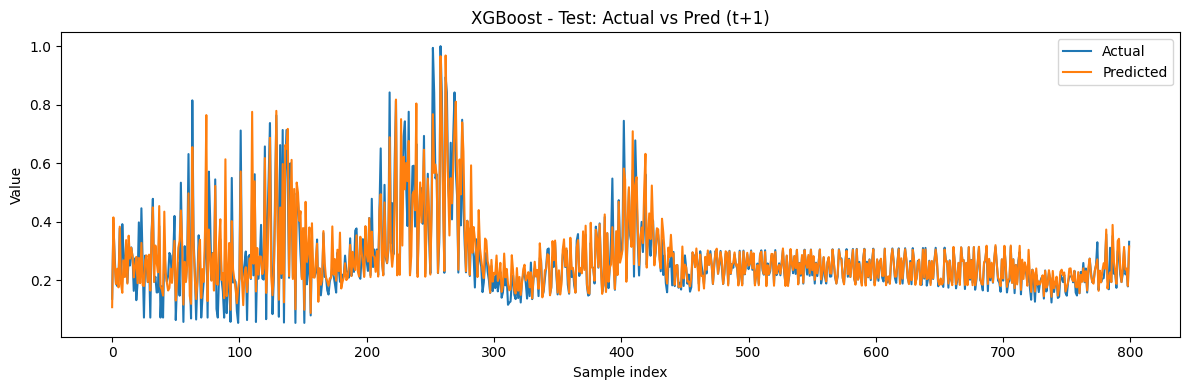

In [22]:
plot_actual_vs_pred(
    y_test, pred_test,
    title="XGBoost - Test: Actual vs Pred (t+1)",
    horizon=0,
    n_points=800
)

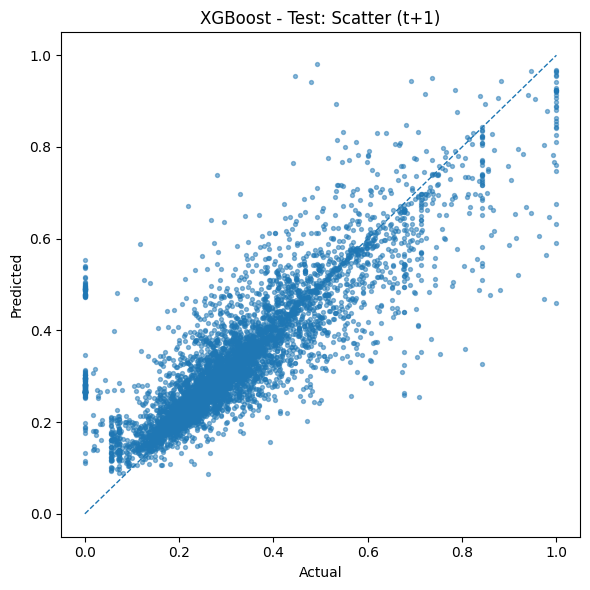

In [23]:
plot_scatter_actual_pred(
    y_test, pred_test,
    title="XGBoost - Test: Scatter (t+1)",
    horizon=0,
    sample=6000
)

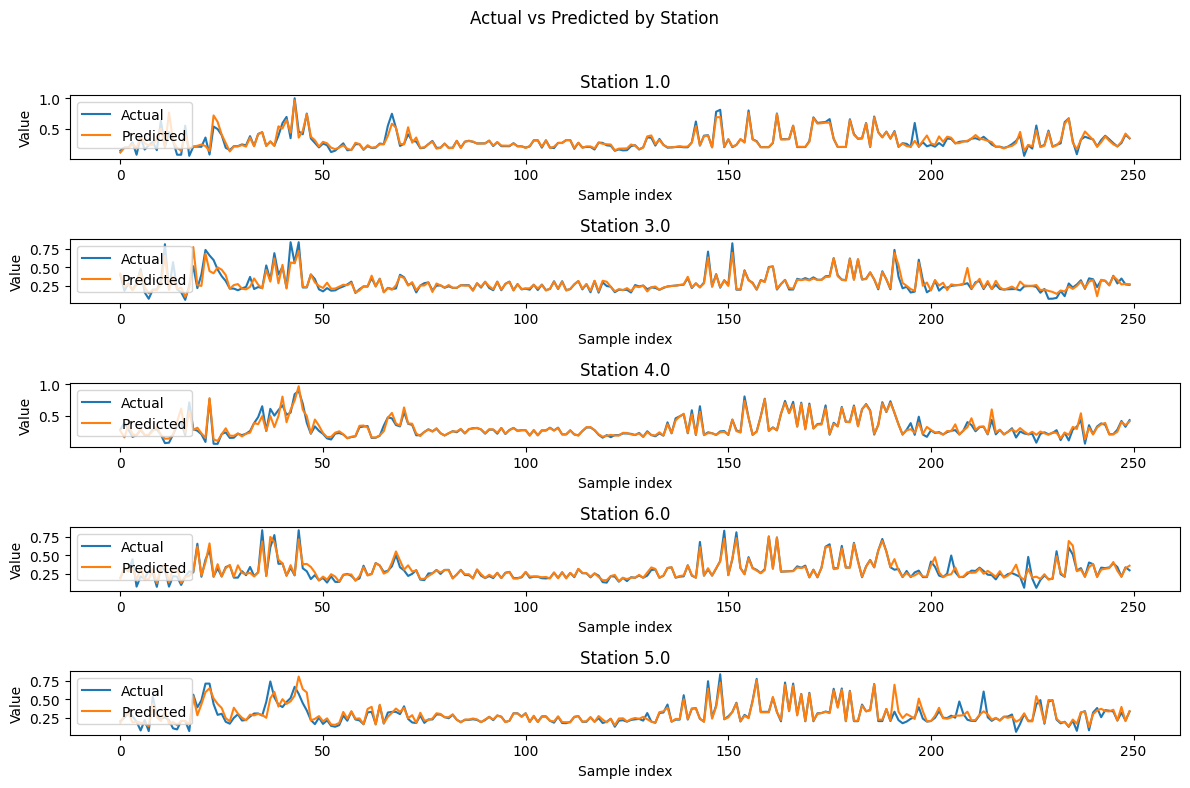

In [ ]:
station_ids_aligned = test_df["Station_No"].values[-len(y_test):]

plot_actual_vs_pred_by_station(
    station_ids=station_ids_aligned,
    y_true=y_test,
    y_pred=pred_test,
    horizon=0,              
    n_points_per_station=250,
    max_stations=5
)